In [1]:
from itertools import product, combinations
from functools import lru_cache
from pathlib import Path
from typing import Callable, Iterable
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## 1. Простой пример: $y=10+2x_1+x_2$
Четыре исходных признака: два полезных, точная копия $x_3=2x_1$ и посторонний $x_4$.

Обучение: все восемь комбинаций $x_1,x_2,x_4\in\{-1,1\}$. Валидация: четыре комбинации $x_1,x_2\in\{-1,1\}$ при $x_4=0$. Это учебные данные **без случайного шума**

In [2]:
base = np.array(list(product([-1.0, 1.0], repeat=3)))
X_toy_train = pd.DataFrame({"x1": base[:, 0], "x2": base[:, 1],
                            "x3": 2 * base[:, 0], "x4": base[:, 2]})
y_toy_train = 10 + 2 * X_toy_train.x1 + X_toy_train.x2

grid = np.array(list(product([-1.0, 1.0], repeat=2)))
X_toy_valid = pd.DataFrame({"x1": grid[:, 0], "x2": grid[:, 1],
                            "x3": 2 * grid[:, 0], "x4": np.zeros(4)})
y_toy_valid = 10 + 2 * X_toy_valid.x1 + X_toy_valid.x2
print("Обучение: 8 строк")
display(X_toy_train.assign(y=y_toy_train).astype(int))
print("Валидация: 4 строки")
display(X_toy_valid.assign(y=y_toy_valid).astype(int))

Обучение: 8 строк


,x1,x2,x3,x4,y
0,-1,-1,-2,-1,7
1,-1,-1,-2,1,7
2,-1,1,-2,-1,9
3,-1,1,-2,1,9
4,1,-1,2,-1,11
5,1,-1,2,1,11
6,1,1,2,-1,13
7,1,1,2,1,13


Валидация: 4 строки


,x1,x2,x3,x4,y
0,-1,-1,-2,0,7
1,-1,1,-2,0,9
2,1,-1,2,0,11
3,1,1,2,0,13


### Шаги 0–2: ошибка $5\rightarrow1\rightarrow0$

Сначала прогнозируем обучающее среднее 10. Затем проверяем каждый признак, выбираем $x_1$ и ищем лучшую добавку к нему. При равенстве $x_1$ и $x_3$ выбираем первый по порядку. После добавления $x_2$ точный ответ восстановлен.

In [3]:
def toy_score(columns: Iterable[str]) -> tuple[float, np.ndarray]:
    cols = list(columns)
    if cols:
        model = LinearRegression().fit(X_toy_train[cols], y_toy_train)
        prediction = model.predict(X_toy_valid[cols])
    else:
        prediction = np.full(len(y_toy_valid), y_toy_train.mean())
    return float(mean_squared_error(y_toy_valid, prediction)), prediction

baseline_mse, baseline_pred = toy_score([])
step1 = pd.DataFrame([{"Признак": c, "MSE": toy_score([c])[0]}
                      for c in X_toy_train.columns])
step2 = pd.DataFrame([{"Добавка к x1": c, "MSE": toy_score(["x1", c])[0]}
                      for c in ["x2", "x3", "x4"]])
print("Без признаков, MSE:", baseline_mse)
display(pd.DataFrame({"y": y_toy_valid, "Прогноз": baseline_pred,
                      "Квадрат ошибки": (y_toy_valid-baseline_pred)**2}))
display(step1.round(6))
display(step2.round(6))
assert np.isclose(baseline_mse, 5.0)
np.testing.assert_allclose(step1.MSE, [1, 4, 1, 5], atol=1e-12)
np.testing.assert_allclose(step2.MSE, [0, 1, 1], atol=1e-12)

Без признаков, MSE: 5.0


,y,Прогноз,Квадрат ошибки
0,7.0,10.0,9.0
1,9.0,10.0,1.0
2,11.0,10.0,1.0
3,13.0,10.0,9.0


,Признак,MSE
0,x1,1.0
1,x2,4.0
2,x3,1.0
3,x4,5.0


,Добавка к x1,MSE
0,x2,0.0
1,x3,1.0
2,x4,1.0


### Фильтр по $R^2$ однофакторной регрессии

Здесь $I(x_j)$ — качество линейной модели с одним признаком и свободным членом на обучающих данных. В этом частном случае $R^2=\mathrm{corr}(x_j,y)^2$.

Топ-2 — $x_1$ и его копия $x_3$: каждый силён отдельно, но второй не добавляет новой информации.

In [4]:
def univariate_r2(X: pd.DataFrame, y: pd.Series | np.ndarray) -> pd.Series:
    scores = {}
    for col in X.columns:
        model = LinearRegression().fit(X[[col]], y)
        scores[col] = r2_score(y, model.predict(X[[col]]))
    return pd.Series(scores, name="R2")

toy_importance = univariate_r2(X_toy_train, y_toy_train)
toy_filter = toy_importance.sort_values(ascending=False, kind="stable").head(2).index.tolist()
display(toy_importance.round(6))
print("Фильтр:", toy_filter, "MSE:", round(toy_score(toy_filter)[0], 6))
print("Forward: ['x1', 'x2'], MSE:", round(toy_score(["x1", "x2"])[0], 6))
assert toy_filter == ["x1", "x3"]
np.testing.assert_allclose(toy_importance.values, [0.8, 0.2, 0.8, 0.0], atol=1e-12)

,R2
x1,0.8
x2,0.2
x3,0.8
x4,0.0


Фильтр: ['x1', 'x3'] MSE: 1.0
Forward: ['x1', 'x2'], MSE: 0.0


## 2. Отдельный эксперимент с шумом: 400 строк, 8 признаков

Теперь $y=10+2x_1+x_2+\varepsilon$, а $x_{3,\mathrm{mix}}=2x_1+x_2+0.6u$. Все исходные случайные величины независимы и стандартно нормальны. Есть ещё пять шумовых столбцов.

Смешанный признак полезен сам по себе, но может стать лишним, когда в модель попадут оба исходных сигнала. Это позволяет увидеть **реальное удаление после добавления** в Stepwise.

300 строк отводим под обучение и внутреннюю кросс-валидацию, 100 — под финальный тест. Размер фильтра $k=2$, штраф обёрток 0.02 и сетка Lasso заданы до оценки на тесте.

In [5]:
rng = np.random.default_rng(42)
raw = rng.normal(size=(400, 8))
raw[:, 2] = 2 * raw[:, 0] + raw[:, 1] + 0.6 * rng.normal(size=400)
y = 10 + 2 * raw[:, 0] + raw[:, 1] + rng.normal(size=400)
X = pd.DataFrame(raw, columns=["x1", "x2", "x3_mix"] + [f"noise_{i}" for i in range(1, 6)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
cv = list(KFold(n_splits=5, shuffle=True, random_state=42).split(X_train))
PENALTY = 0.02
FILTER_K = 2
print("Train:", X_train.shape, "Test:", X_test.shape)
display(X_train.head().round(3))

Train: (300, 8) Test: (100, 8)


,x1,x2,x3_mix,noise_1,noise_2,noise_3,noise_4,noise_5
247,-1.893,0.217,-2.982,0.489,0.171,-0.560,0.031,-0.252
110,0.226,0.948,1.095,-1.172,-1.093,0.289,1.245,-0.431
16,-0.640,-0.927,-2.996,-1.377,0.635,-0.222,-1.471,-1.016
66,0.258,1.565,0.432,-0.941,-0.449,0.452,-1.566,0.637
153,-0.901,0.524,-1.761,-0.577,0.560,0.566,-0.550,-1.123


### Единый критерий обёрток

На каждом из пяти фолдов обучаем новую линейную регрессию, усредняем валидационную MSE, добавляем штраф за число признаков. Пустой набор оцениваем константной моделью. Кэширование только экономит повторные вычисления одного и того же набора.

$Q$ используется **для поиска**, а не как итоговая независимая оценка. Финальные ошибки ниже считаются без штрафа на тесте. Значение 0.02 зависит от масштаба целевой переменной; на другой задаче его надо выбирать отдельно внутри обучающей части.

In [6]:
@lru_cache(maxsize=None)
def cv_mse_cached(columns: tuple[str, ...]) -> float:
    if columns:
        estimator = LinearRegression()
        data = X_train[list(columns)]
    else:
        estimator = DummyRegressor(strategy="mean")
        data = np.zeros((len(y_train), 1))
    return float(-cross_val_score(estimator, data, y_train, cv=cv,
                                   scoring="neg_mean_squared_error").mean())

def Q(columns: Iterable[str]) -> float:
    cols = tuple(sorted(columns))
    return cv_mse_cached(cols) + PENALTY * len(cols)

baseline_cv_mse = Q(())
print("Q пустой модели:", round(baseline_cv_mse, 6))

Q пустой модели: 5.48962


### Forward и Backward

Forward начинает с пустого набора и проверяет все добавления одного признака. Backward начинает с полного набора и проверяет все удаления. Принимается только шаг, уменьшающий Q. Это один из вариантов правила остановки; альтернативно можно заранее зафиксировать размер набора.

In [7]:
Score = Callable[[tuple[str, ...]], float]

def best_of(subsets: list[tuple[str, ...]], score: Score) -> tuple[str, ...] | None:
    if not subsets:
        return None
    # Deterministic tie-break: score, then size, then column names.
    return min(subsets, key=lambda s: (round(score(s), 12), len(s), s))

def one_way(columns: Iterable[str], score: Score, direction: str,
            tol: float = 1e-9) -> tuple[list[str], pd.DataFrame]:
    if direction not in {"forward", "backward"}:
        raise ValueError("direction must be 'forward' or 'backward'")
    if tol < 0:
        raise ValueError("tol must be non-negative")
    universe = tuple(sorted(columns))
    selected = () if direction == "forward" else universe
    history = [{"action": "start", "subset": selected, "Q": score(selected)}]
    while True:
        if direction == "forward":
            candidates = [tuple(sorted(selected + (c,))) for c in universe if c not in selected]
        else:
            candidates = [tuple(c for c in selected if c != removed) for removed in selected]
        best = best_of(candidates, score)
        if best is None or score(selected) - score(best) <= tol:
            return list(selected), pd.DataFrame(history)
        changed = sorted(set(best).symmetric_difference(selected))[0]
        action = ("+ " if direction == "forward" else "- ") + changed
        selected = best
        history.append({"action": action, "subset": selected, "Q": score(selected)})

### Stepwise: добавление, затем повторная проверка удалений

После успешного добавления алгоритм пытается убрать любой из уже выбранных признаков, пока удаления улучшают Q. Удалённый признак позднее снова может стать кандидатом на добавление. Поиск завершается, когда ни добавление, ни удаление не помогают.

Ниже самостоятельная реализация **двунаправленного** поиска, а не последовательное применение двух однонаправленных селекторов. Каждое принятое изменение строго уменьшает один и тот же критерий: это исключает циклы при детерминированной оценке.

In [8]:
def stepwise(columns: Iterable[str], score: Score,
             tol: float = 1e-9, max_steps: int = 1000) -> tuple[list[str], pd.DataFrame]:
    if tol < 0 or max_steps < 1:
        raise ValueError("Require tol >= 0 and max_steps >= 1")
    universe = tuple(sorted(columns))
    selected: tuple[str, ...] = ()
    history = [{"action": "start", "subset": selected, "Q": score(selected)}]
    for _ in range(max_steps):
        changed = False
        additions = [tuple(sorted(selected + (c,))) for c in universe if c not in selected]
        best = best_of(additions, score)
        if best is not None and score(selected) - score(best) > tol:
            added = next(iter(set(best) - set(selected)))
            selected = best
            history.append({"action": "+ " + added, "subset": selected, "Q": score(selected)})
            changed = True
        # Revisit all retained variables after every addition.
        while selected:
            removals = [tuple(c for c in selected if c != removed) for removed in selected]
            best = best_of(removals, score)
            if best is None or score(selected) - score(best) <= tol:
                break
            removed = next(iter(set(selected) - set(best)))
            selected = best
            history.append({"action": "- " + removed, "subset": selected, "Q": score(selected)})
            changed = True
        if not changed:
            return list(selected), pd.DataFrame(history)
    raise RuntimeError("Search did not converge within max_steps")

### Best subsets: полный перебор

Перебираем все $2^d$ подмножеств, включая пустую модель, и находим глобальный минимум **заданного вычисляемого Q**. Это не гарантия лучшего качества на будущих данных. При $d=8$ проверяется 256 наборов, при $d=20$ — уже 1 048 576. Для большого числа признаков код специально ограничен, чтобы случайно не запустить очень долгий расчёт.

In [9]:
def best_subsets(columns: Iterable[str], score: Score,
                 max_features: int = 15) -> tuple[list[str], pd.DataFrame]:
    universe = tuple(sorted(columns))
    if len(universe) > max_features:
        raise ValueError(f"Exhaustive search is limited to {max_features} features")
    candidates = [s for k in range(len(universe) + 1) for s in combinations(universe, k)]
    best = best_of(candidates, score)
    table = pd.DataFrame([{"subset": s, "n_features": len(s), "Q": score(s)} for s in candidates])
    return list(best), table.sort_values(["Q", "n_features"], kind="stable").reset_index(drop=True)

### Запуск четырёх обёрток

Проверяем, что на каждом принятом шаге Q уменьшается, и что Stepwise действительно выполняет удаление. Все результаты на этом этапе основаны только на обучающей части.

In [10]:
forward_cols, forward_path = one_way(X_train.columns, Q, "forward")
backward_cols, backward_path = one_way(X_train.columns, Q, "backward")
stepwise_cols, stepwise_path = stepwise(X_train.columns, Q)
best_cols, exhaustive_table = best_subsets(X_train.columns, Q)

for title, path in [("Forward", forward_path), ("Backward", backward_path), ("Stepwise", stepwise_path)]:
    print(title)
    display(path.round({"Q": 6}))
    assert (np.diff(path.Q) < -1e-9).all()
print("Best subsets:", best_cols, "Проверено наборов:", len(exhaustive_table))
display(exhaustive_table.head(6).round({"Q": 6}))
assert len(exhaustive_table) == 2 ** X_train.shape[1]
assert stepwise_path.action.str.startswith("- ").any()
assert set(stepwise_cols) == {"x1", "x2"}
assert Q(tuple(best_cols)) <= Q(tuple(stepwise_cols)) + 1e-9

Forward


,action,subset,Q
0,start,(),5.489620
1,+ x3_mix,"(x3_mix,)",1.410942
2,+ x1,"(x1, x3_mix)",1.374708
3,+ x2,"(x1, x2, x3_mix)",1.071550


Backward


,action,subset,Q
0,start,"(noise_1, noise_2, noise_3, noise_4, noise_5, ...",1.180232
1,- noise_1,"(noise_2, noise_3, noise_4, noise_5, x1, x2, x...",1.153352
2,- noise_4,"(noise_2, noise_3, noise_5, x1, x2, x3_mix)",1.129011
3,- noise_3,"(noise_2, noise_5, x1, x2, x3_mix)",1.106215
4,- noise_2,"(noise_5, x1, x2, x3_mix)",1.084141
5,- x3_mix,"(noise_5, x1, x2)",1.065883
6,- noise_5,"(x1, x2)",1.053448


Stepwise


,action,subset,Q
0,start,(),5.489620
1,+ x3_mix,"(x3_mix,)",1.410942
2,+ x1,"(x1, x3_mix)",1.374708
3,+ x2,"(x1, x2, x3_mix)",1.071550
4,- x3_mix,"(x1, x2)",1.053448


Best subsets: ['x1', 'x2'] Проверено наборов: 256


,subset,n_features,Q
0,"(x1, x2)",2,1.053448
1,"(noise_5, x1, x2)",3,1.065883
2,"(x1, x2, x3_mix)",3,1.071550
3,"(noise_2, x1, x2)",3,1.073648
4,"(noise_3, x1, x2)",3,1.077428
5,"(noise_4, x1, x2)",3,1.078254


### Фильтр и встроенный метод Lasso

Фильтр ранжирует признаки по $R^2$ отдельных линейных регрессий и оставляет два. В Lasso коэффициент регуляризации выбирается по пяти фолдам внутри обучающей части; стандартизация находится внутри Pipeline и переобучается на каждом фолде.

Это **сравнение заранее заданных процедур**, не равенство всех ограничений: у фильтра фиксировано k, у обёрток штраф на число переменных, у Lasso штраф на величину коэффициентов.

In [11]:
importance = univariate_r2(X_train, y_train)
filter_cols = importance.sort_values(ascending=False, kind="stable").head(FILTER_K).index.tolist()
lasso_search = GridSearchCV(
    make_pipeline(StandardScaler(), Lasso(max_iter=30000, tol=1e-8)),
    {"lasso__alpha": np.logspace(-2, 0, 21)},
    scoring="neg_mean_squared_error", cv=cv,
).fit(X_train, y_train)
lasso = lasso_search.best_estimator_
lasso_coef = lasso.named_steps["lasso"].coef_
lasso_cols = X_train.columns[np.abs(lasso_coef) > 1e-8].tolist()

subsets = {"Без отбора": X_train.columns.tolist(), "Фильтр R², k=2": filter_cols,
           "Best subsets": best_cols, "Forward": forward_cols,
           "Backward": backward_cols, "Stepwise": stepwise_cols}
fitted = {name: LinearRegression().fit(X_train[cols], y_train) for name, cols in subsets.items()}
print("Фильтр:", filter_cols)
print("Lasso alpha:", lasso_search.best_params_["lasso__alpha"])
display(importance.sort_values(ascending=False).round(5))
print("Все процедуры зафиксированы до просмотра тестовых ошибок.")

Фильтр: ['x3_mix', 'x1']
Lasso alpha: 0.03162277660168379


,R2
x3_mix,0.74961
x1,0.63199
x2,0.19988
noise_5,0.00655
noise_1,0.00612
noise_4,0.00362
noise_2,0.00186
noise_3,0.00122


Все процедуры зафиксированы до просмотра тестовых ошибок.


In [12]:
rows = []
for name, cols in subsets.items():
    rows.append({"Метод": name, "Признаков": len(cols), "Набор": ", ".join(cols),
                 "Test MSE": float(mean_squared_error(y_test, fitted[name].predict(X_test[cols])))})
rows.append({"Метод": "Lasso", "Признаков": len(lasso_cols), "Набор": ", ".join(lasso_cols),
             "Test MSE": float(mean_squared_error(y_test, lasso.predict(X_test)))})
results_table = pd.DataFrame(rows)
display(results_table.round({"Test MSE": 6}))

,Метод,Признаков,Набор,Test MSE
0,Без отбора,8,"x1, x2, x3_mix, noise_1, noise_2, noise_3, noi...",0.920482
1,"Фильтр R², k=2",2,"x3_mix, x1",1.324766
2,Best subsets,2,"x1, x2",0.947686
3,Forward,3,"x1, x2, x3_mix",0.943656
4,Backward,2,"x1, x2",0.947686
5,Stepwise,2,"x1, x2",0.947686
6,Lasso,5,"x1, x2, noise_1, noise_2, noise_5",0.927997


### Графики

Первая диаграмма воспроизводит точный пример; вторая показывает путь двунаправленного поиска; третья — тестовую ошибку всех процедур.

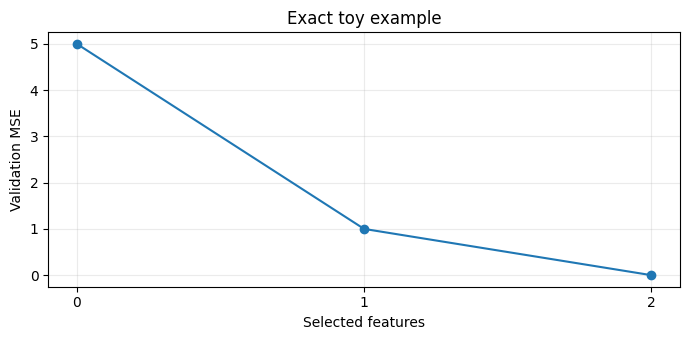

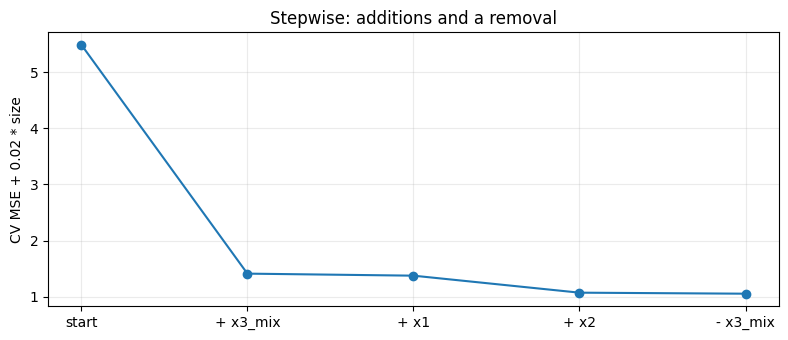

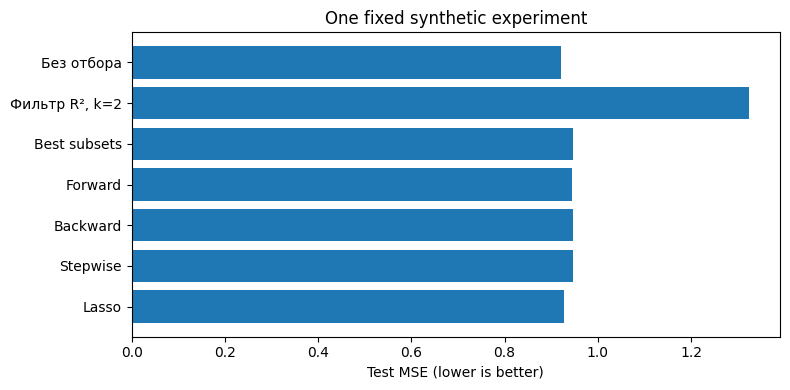

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot([0, 1, 2], [5, 1, 0], marker="o")
ax.set(xticks=[0, 1, 2], xlabel="Selected features", ylabel="Validation MSE", title="Exact toy example")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(len(stepwise_path)), stepwise_path.Q, marker="o")
ax.set(xticks=range(len(stepwise_path)), xticklabels=stepwise_path.action,
       ylabel="CV MSE + 0.02 * size", title="Stepwise: additions and a removal")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results_table["Метод"], results_table["Test MSE"])
ax.invert_yaxis()
ax.set(xlabel="Test MSE (lower is better)", title="One fixed synthetic experiment")
plt.tight_layout()
plt.show()

## 4. Сохранение результатов

`results_v3.json` содержит значения для таблиц и схем презентации. Файл появится в текущем каталоге блокнота.

In [14]:
result = {
    "versions": versions,
    "toy": {"train": X_toy_train.assign(y=y_toy_train).to_dict(orient="records"),
            "validation": X_toy_valid.assign(y=y_toy_valid).to_dict(orient="records"),
            "step1": step1.to_dict(orient="records"), "step2": step2.to_dict(orient="records"),
            "mse_path": [baseline_mse, toy_score(["x1"])[0], toy_score(["x1", "x2"])[0]],
            "importance_r2": toy_importance.to_dict()},
    "experiment": {"n_train": len(y_train), "n_test": len(y_test), "n_features": X.shape[1],
                   "penalty": PENALTY, "rows": rows,
                   "forward_path": forward_path.to_dict(orient="records"),
                   "backward_path": backward_path.to_dict(orient="records"),
                   "stepwise_path": stepwise_path.to_dict(orient="records"),
                   "best_subsets_count": len(exhaustive_table),
                   "lasso_alpha": float(lasso_search.best_params_["lasso__alpha"])},
}
Path("results_v3.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сохранено: results_v3.json")

Сохранено: results_v3.json
